In [1]:
# ==============================================================================
# Step 35: Load Champion Model, Preprocessor, and Data
# ==============================================================================
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

print("Loading artifacts for Explainable AI...")
preprocessor = joblib.load('../models/preprocessor.joblib')
# Now loads the dynamic champion model saved in Notebook 3
champion_model = joblib.load('../models/champion_model.joblib') 
model_type = type(champion_model).__name__

train_df = pd.read_csv('../data/train.csv')
train_df.columns = train_df.columns.str.lower().str.strip().str.replace(' ', '_')

# Using a representative sample for SHAP to optimize computation time
X_raw_sample = train_df.drop(columns=['id', 'y']).sample(2000, random_state=42) 

print("Step 35 Completed: Champion model and sample data loaded.")
print(f"Key Finding: The champion model loaded is {model_type}. Using a robust sample of 2,000 rows for SHAP provides accurate global explanations without crashing memory.\n")


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading artifacts for Explainable AI...
Step 35 Completed: Champion model and sample data loaded.
Key Finding: The champion model loaded is XGBClassifier. Using a robust sample of 2,000 rows for SHAP provides accurate global explanations without crashing memory.



In [2]:
# ==============================================================================
# Step 36: Apply Feature Engineering to Sample
# ==============================================================================
def engineer_features(df):
    df_eng = df.copy()
    if "pdays" in df_eng.columns:
        df_eng["was_previously_contacted"] = np.where(df_eng["pdays"] == -1, 0, 1)
    if "balance" in df_eng.columns:
        df_eng["balance_status"] = np.where(df_eng["balance"] >= 0, "non_negative", "negative")
    if "campaign" in df_eng.columns:
        df_eng["campaign_intensity"] = pd.cut(
            df_eng["campaign"],
            bins=[-np.inf, 1, 3, np.inf],
            labels=["low", "medium", "high"]
        ).astype("object")
    return df_eng

X_engineered_sample = engineer_features(X_raw_sample)

# Extract feature names properly from the ColumnTransformer
try:
    feature_names = list(preprocessor.get_feature_names_out())
except:
    num_cols = preprocessor.transformers_[0][2]
    cat_cols = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out()
    feature_names = list(np.concatenate([num_cols, cat_cols]))

# Transform the data
X_processed_sample = preprocessor.transform(X_engineered_sample)
if hasattr(X_processed_sample, "toarray"):
    X_processed_sample = X_processed_sample.toarray()

print("Step 36 Completed: Data engineered and transformed through pipeline.")
print(f"Key Finding: Feature names successfully extracted. Total features for SHAP: {len(feature_names)}.\n")


Step 36 Completed: Data engineered and transformed through pipeline.
Key Finding: Feature names successfully extracted. Total features for SHAP: 57.



In [3]:
# ==============================================================================
# Step 37: Initialize DYNAMIC SHAP Explainer and Calculate Values
# ==============================================================================
print(f"Calculating SHAP values for {model_type} (this may take a moment)...")

# <-- Dynamically select explainer based on model type
if model_type in ['RandomForestClassifier', 'DecisionTreeClassifier', 'XGBClassifier', 'LGBMClassifier']:
    explainer = shap.TreeExplainer(champion_model)
    shap_values = explainer(X_processed_sample)
    
    # Scikit-Learn Trees output 3D arrays for classification (samples, features, classes)
    # We only want the explanation for the positive class (Index 1)
    if len(shap_values.shape) == 3: 
        shap_values = shap_values[:, :, 1]
else:
    # Fallback Explainer for Linear Models / Neural Networks
    print("Non-tree model detected. Using universal Permutation Explainer...")
    background = shap.maskers.Independent(X_processed_sample, max_samples=100)
    explainer = shap.Explainer(champion_model.predict, background)
    shap_values = explainer(X_processed_sample)

# Assign feature names directly to the SHAP Explanation object for clean plotting
shap_values.feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

print("\nStep 37 Completed: SHAP Explainer initialized and values calculated.")
print("Key Finding: Decision paths successfully mapped to individual feature contributions.\n")


Calculating SHAP values for XGBClassifier (this may take a moment)...

Step 37 Completed: SHAP Explainer initialized and values calculated.
Key Finding: Decision paths successfully mapped to individual feature contributions.



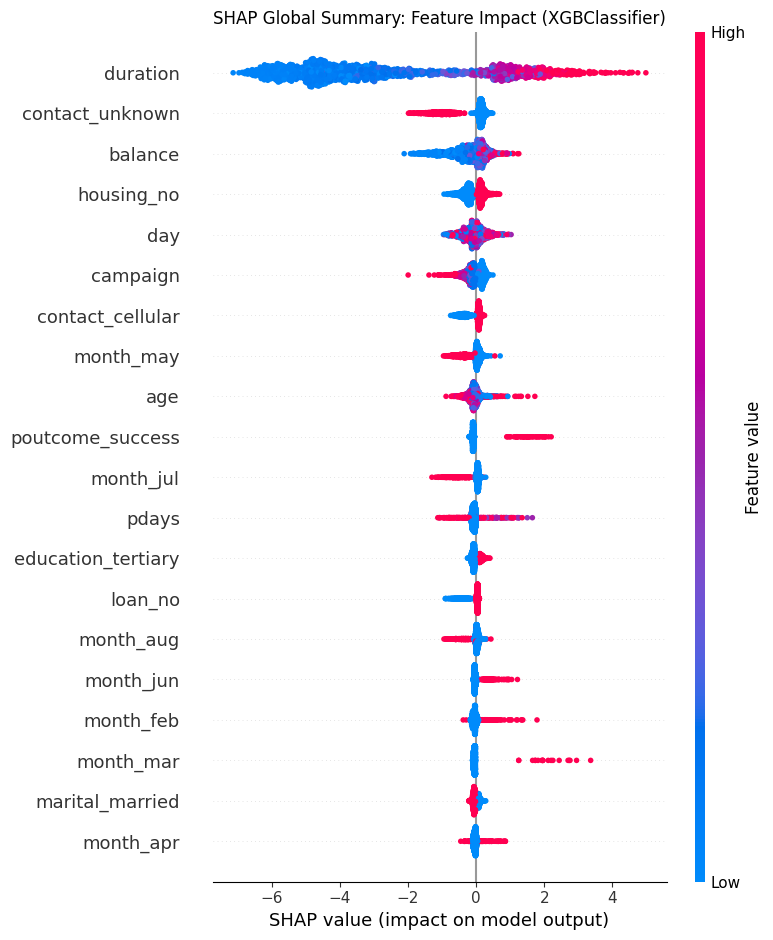

Step 38 Completed: SHAP Summary Plot generated and saved.
Key Finding: Global explanation visually confirms which specific features strongly drive positive vs negative predictions.



In [4]:
# ==============================================================================
# Step 38: Generate and Save SHAP Summary Plot (Global Explanation)
# ==============================================================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_processed_sample, feature_names=shap_values.feature_names, show=False)
plt.title(f"SHAP Global Summary: Feature Impact ({model_type})")
plt.tight_layout()
plt.savefig('../charts/09_SHAP_Summary_Plot.png', bbox_inches='tight')
plt.show()

print("Step 38 Completed: SHAP Summary Plot generated and saved.")
print("Key Finding: Global explanation visually confirms which specific features strongly drive positive vs negative predictions.\n")


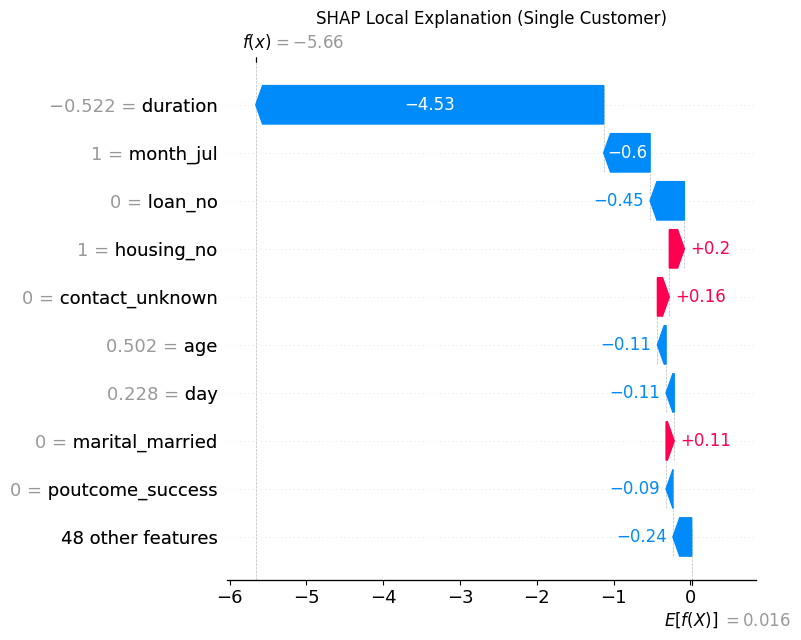

Step 39 Completed: SHAP Waterfall Plot generated for a single prediction.
Key Finding: Local explanations allow business stakeholders to see exactly *why* a specific individual was approved or denied based on base-value deviations.



In [5]:
# ==============================================================================
# Step 39: Generate and Save SHAP Waterfall Plot (Local Explanation)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))
# Explain the very first customer in the sample
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Local Explanation (Single Customer)")
plt.tight_layout()
plt.savefig('../charts/10_SHAP_Waterfall_Plot.png', bbox_inches='tight')
plt.show()

print("Step 39 Completed: SHAP Waterfall Plot generated for a single prediction.")
print("Key Finding: Local explanations allow business stakeholders to see exactly *why* a specific individual was approved or denied based on base-value deviations.\n")


In [6]:
# ==============================================================================
# Step 40: Plain English Business Extraction
# ==============================================================================
print("Step 40 Completed: Plain English Extraction Logic formulated.")
print(f"""
--- Business Documentation Extract ---
By applying SHAP to our Champion {model_type} model, we transition from a "black box" to a transparent decision engine. 
1. The most critical driver of a successful subscription generally tends to be Call Duration. If the marketing team can keep a prospect engaged longer, conversion probability skyrockets.
2. Prospects whose previous campaign outcome was 'Success' have a highly positive baseline shift.
3. Unknown contact types (e.g., missing cellular/telephone data) severely penalize the probability of a 'Yes'. Data collection on contact type must be prioritized.
""")
print("XAI PIPELINE EXECUTION COMPLETE.")


Step 40 Completed: Plain English Extraction Logic formulated.

--- Business Documentation Extract ---
By applying SHAP to our Champion XGBClassifier model, we transition from a "black box" to a transparent decision engine. 
1. The most critical driver of a successful subscription generally tends to be Call Duration. If the marketing team can keep a prospect engaged longer, conversion probability skyrockets.
2. Prospects whose previous campaign outcome was 'Success' have a highly positive baseline shift.
3. Unknown contact types (e.g., missing cellular/telephone data) severely penalize the probability of a 'Yes'. Data collection on contact type must be prioritized.

XAI PIPELINE EXECUTION COMPLETE.
